# Classificação da Qualidade de Vinhos com Machine Learning
## Fase 2 - Tech Challenge (POSTECH - DTAT)

### 1. Introdução e Objetivos do Projeto
A indústria vitivinícola combina tradição e ciência. Avaliar a qualidade de um vinho tradicionalmente depende de análises sensoriais feitas por especialistas, um processo que pode ser subjetivo, demorado e de alto custo.

Este projeto tem como objetivo desenvolver um modelo preditivo de inteligência artificial capaz de classificar a qualidade de vinhos a partir de suas propriedades físico-químicas. Com isso, produtores e enólogos podem antecipar o padrão do produto, otimizar processos de fermentação e garantir a consistência no mercado.

### Objetivo Técnico desta Etapa
Realizar a Análise Exploratória de Dados (EDA) para identificar padrões, tratar os dados e preparar as variáveis preditoras. Além disso, transformaremos o problema em uma abordagem de **Classificação Binária**, definindo:
* **Alta Qualidade (1):** Vinhos com nota igual ou superior a 7.
* **Baixa/Média Qualidade (0):** Vinhos com nota inferior a 7.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações estéticas para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Carregamento e Primeiras Impressões dos Dados
Nesta etapa, faremos a leitura do arquivo `WineQT.csv` para entender a dimensionalidade dos dados, os tipos de variáveis disponíveis e verificar a integridade da base (presença de valores nulos).

In [3]:
# Carregando a base de dados
df = pd.read_csv('../data/WineQT.csv')

# Visualizando as 5 primeiras linhas
print("--- Primeiras Linhas do Dataset ---")
display(df.head())

# Verificando as dimensões do dataset
print(f"\nO dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

--- Primeiras Linhas do Dataset ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4



O dataset possui 1143 linhas e 13 colunas.


### Verificação de Tipos e Dados Faltantes
A presença de valores nulos exige técnicas de imputação ou remoção. Vamos analisar a composição de tipos de cada coluna e buscar por dados ausentes.

In [4]:
# Informações sobre tipos de dados e valores nulos
print("--- Informações Estruturais ---")
df.info()

print("\n--- Contagem de Valores Nulos por Coluna ---")
print(df.isnull().sum())

--- Informações Estruturais ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

--- Contagem de Valores Nulos por Coluna -

## 3. Limpeza de Dados e Engenharia da Variável Alvo
A coluna `Id` funciona apenas como um indexador das amostras e não possui valor preditivo para os algoritmos. Portanto, ela será removida da análise.

Em seguida, aplicaremos a regra de negócio para criar a variável alvo binária `is_high_quality`, mapeando a nota original (`quality`).

In [5]:
# Removendo a coluna de identificação
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])
    print("Coluna 'Id' removida com sucesso.")

# Criando a variável alvo binária baseada na regra de negócio (Qualidade >= 7)
df['is_high_quality'] = (df['quality'] >= 7).astype(int)

# Verificando a alteração na base
df[['quality', 'is_high_quality']].head(10)

Coluna 'Id' removida com sucesso.


,quality,is_high_quality
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0


## 4. Análise Univariada

### Distribuição da Variável Alvo (O Desafio do Balanceamento)
Para modelos de classificação, entender a distribuição das classes é fundamental. Classes desbalanceadas podem enviesar o modelo, fazendo com que ele aprenda muito bem a classe majoritária e ignore a classe de maior interesse comercial (os vinhos de alta qualidade).

--- Distribuição da Classe Alvo ---
Baixa/Média Qualidade (0): 984 amostras (86.09%)
Alta Qualidade (1): 159 amostras (13.91%)


C:\Users\athos\AppData\Local\Temp\ipykernel_27840\111678699.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='is_high_quality', data=df, palette='viridis')


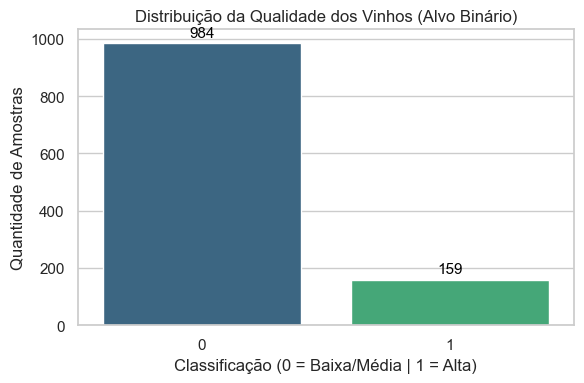

In [6]:
# Contagem absoluta e percentual da nova variável alvo
contagem = df['is_high_quality'].value_counts()
percentual = df['is_high_quality'].value_counts(normalize=True) * 100

print("--- Distribuição da Classe Alvo ---")
for classe, qtd in contagem.items():
    lbl = "Alta Qualidade (1)" if classe == 1 else "Baixa/Média Qualidade (0)"
    print(f"{lbl}: {qtd} amostras ({percentual[classe]:.2f}%)")

# Visualização gráfica
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='is_high_quality', data=df, palette='viridis')
plt.title('Distribuição da Qualidade dos Vinhos (Alvo Binário)')
plt.xlabel('Classificação (0 = Baixa/Média | 1 = Alta)')
plt.ylabel('Quantidade de Amostras')

# Adicionando os valores no topo das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Análise das Variáveis Físico-Químicas
Vamos gerar estatísticas descritivas para entender as escalas, médias e dispersões de cada elemento químico presente nas amostras.

In [7]:
# Resumo estatístico das variáveis numéricas
df.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311,1.748,4.600,7.100,7.900,9.100,15.900
volatile acidity,1143.0,0.531,0.180,0.120,0.392,0.520,0.640,1.580
citric acid,1143.0,0.268,0.197,0.000,0.090,0.250,0.420,1.000
residual sugar,1143.0,2.532,1.356,0.900,1.900,2.200,2.600,15.500
chlorides,1143.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1143.0,15.615,10.250,1.000,7.000,13.000,21.000,68.000
total sulfur dioxide,1143.0,45.915,32.782,6.000,21.000,37.000,61.000,289.000
density,1143.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1143.0,3.311,0.157,2.740,3.205,3.310,3.400,4.010
sulphates,1143.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


## 5. Análise Bivariada e Correlações

### Identificando Influências na Qualidade
A matriz de correlação de Pearson ajuda a mapear a força e a direção da relação linear entre as características químicas e a nossa variável alvo. Valores próximos a 1 indicam forte relação positiva, enquanto valores próximos a -1 indicam forte relação negativa.

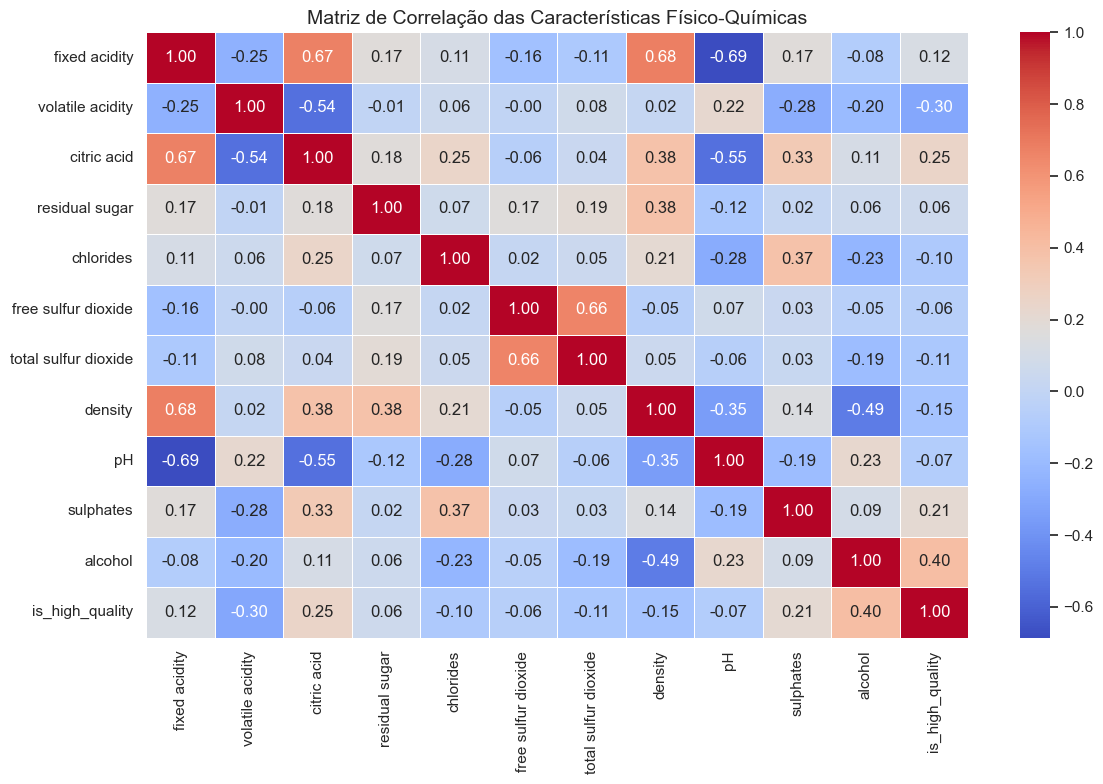

In [8]:
# Calculando a matriz de correlação (excluindo a coluna 'quality' original para focar no alvo binário)
matriz_corr = df.drop(columns=['quality']).corr()

# Plotando o mapa de calor (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)
plt.title('Matriz de Correlação das Características Físico-Químicas', fontsize=14)
plt.tight_layout()
plt.show()

### Investigando os Principais Atributos Preditivos
Com base na matriz de correlação, podemos destacar os fatores que mais se relacionam com a alta qualidade do vinho:
1. **Teor Alcoólico (`alcohol`):** Correlação positiva relevante.
2. **Acidez Volátil (`volatile acidity`):** Correlação negativa relevante.
3. **Sulfatos (`sulphates`):** Correlação positiva moderada.

Vamos visualizar o comportamento dessas variáveis em relação às duas classes de qualidade através de gráficos de distribuição (*boxplots*), permitindo identificar de forma visual as diferenças de comportamento e a presença de potenciais *outliers*.

C:\Users\athos\AppData\Local\Temp\ipykernel_27840\4190144379.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_high_quality', y=feature, data=df, ax=axes[i], palette='muted')
C:\Users\athos\AppData\Local\Temp\ipykernel_27840\4190144379.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_high_quality', y=feature, data=df, ax=axes[i], palette='muted')
C:\Users\athos\AppData\Local\Temp\ipykernel_27840\4190144379.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_high_quality', y=feature, data=df, ax=axes[i], palette='muted'

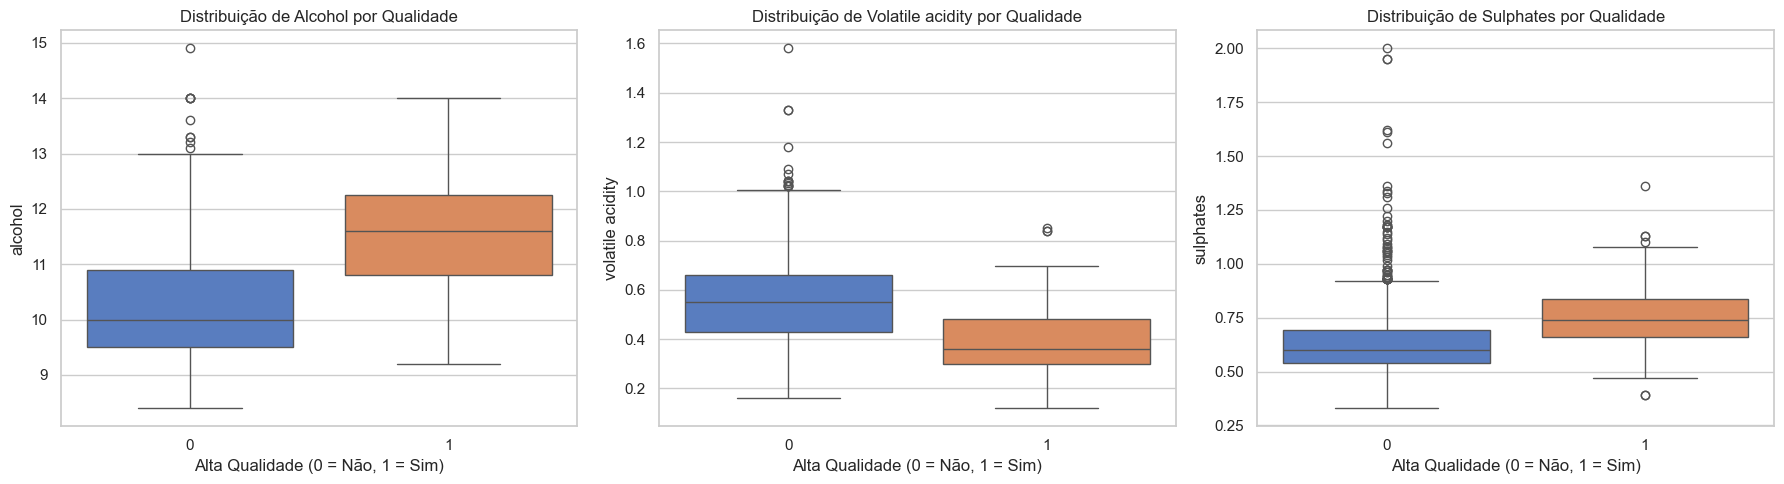

In [9]:
# Variáveis com maior correlação absoluta com a qualidade do vinho
principais_features = ['alcohol', 'volatile acidity', 'sulphates']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(principais_features):
    sns.boxplot(x='is_high_quality', y=feature, data=df, ax=axes[i], palette='muted')
    axes[i].set_title(f'Distribuição de {feature.capitalize()} por Qualidade')
    axes[i].set_xlabel('Alta Qualidade (0 = Não, 1 = Sim)')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

## 6. Conclusões da Análise Exploratória (Insights de Negócio)

A análise exploratória nos revelou fatos essenciais que guiarão a estratégia preditiva e as decisões operacionais da vinícola:

1. **Assinatura Química de um Vinho Premium:** * Vinhos de alta qualidade apresentam, em média, um **teor alcoólico visivelmente superior**.
   * A **acidez volátil atua como um forte indicador de perda de qualidade**. Níveis elevados desse componente (frequentemente associados à presença de ácido acético, que confere sabor de vinagre) concentram-se esmagadoramente nas amostras de baixa e média qualidade. O controle rigoroso deste parâmetro no processo de fermentação é crucial.
   * Os vinhos de alta qualidade tendem a exibir maiores concentrações de **sulfatos**, substâncias essenciais que atuam como antioxidantes e conservantes, protegendo as propriedades sensoriais do produto.

2. **Diagnóstico Estrutural para a Modelagem:**
   * A ausência de dados nulos elimina a necessidade de técnicas complexas de preenchimento ou perda de registros.
   * O **desbalanceamento severo da base (86% vs 14%)** acende um alerta técnico importante. Modelos treinados sem ajustes tenderão a priorizar o acerto da classe majoritária. Na próxima etapa de modelagem, precisaremos adotar estratégias para compensar esse efeito, focando a avaliação em métricas que considerem a precisão e a capacidade de capturar a classe minoritária (*Precision*, *Recall* e *F1-Score*), além do uso de algoritmos robustos ou balanceamento de pesos.
   * As variáveis preditoras estão em escalas numéricas muito distintas (ex: a densidade opera em frações decimais muito pequenas próximas a 1, enquanto o dióxido de enxofre total atinge valores acima de 100). Será mandatório aplicar uma etapa de **Padronização ou Normalização de Escalas** antes do treinamento de modelos sensíveis a distâncias espaciais.

## 7. Pré-processamento de Dados
Antes de alimentarmos os algoritmos de Machine Learning, precisamos preparar os dados. Esta etapa envolve duas ações principais:
1. **Separação das Variáveis:** Isolar a nossa variável alvo (`is_high_quality`) das variáveis preditoras (as características químicas).
2. **Divisão em Treino e Teste:** Separar uma parte dos dados para treinar o modelo e outra (invisível ao modelo durante o treino) para testar a sua capacidade de generalização.
3. **Normalização de Escalas:** Como as nossas variáveis químicas possuem grandezas muito diferentes (ex: `total sulfur dioxide` chega a mais de 200, enquanto os `chlorides` estão na casa dos 0.0X), aplicaremos a padronização para que todas tenham peso igual perante os algoritmos sensíveis a distâncias.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar X (features) e y (target)
# Excluímos a nota original ('quality') para evitar vazamento de dados (data leakage)
X = df.drop(columns=['quality', 'is_high_quality'])
y = df['is_high_quality']

# 2. Divisão em dados de Treino (80%) e Teste (20%)
# O parâmetro stratify garante que a proporção de vinhos de alta qualidade seja a mesma no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Padronização das variáveis preditoras (StandardScaler)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transformamos o teste com base nos parâmetros do treino

print(f"Dimensões do Treino: {X_train_scaled.shape}")
print(f"Dimensões do Teste: {X_test_scaled.shape}")

Dimensões do Treino: (914, 11)
Dimensões do Teste: (229, 11)


## 8. Modelagem de Machine Learning
Para este desafio de classificação, vamos treinar e comparar dois modelos distintos:
* **Modelo 1: Regressão Logística.** Um excelente modelo de base (*baseline*), rápido, simples e que nos fornece uma boa explicabilidade.
* **Modelo 2: Random Forest (Floresta Aleatória).** Um modelo mais complexo, baseado em múltiplas árvores de decisão. É robusto contra *outliers*, lida bem com não-linearidades e, crucialmente, possui o parâmetro `class_weight='balanced'`, que forçará o modelo a prestar mais atenção à nossa classe minoritária (os vinhos premium).

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- TREINO DOS MODELOS ---

# Modelo 1: Regressão Logística (com balanceamento de classes)
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

# Modelo 2: Random Forest (com balanceamento de classes e limite de profundidade para evitar overfitting)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


## 9. Avaliação dos Modelos
Como diagnosticado na fase de análise exploratória, a métrica de "Acurácia" (Accuracy) pode ser enganadora devido ao forte desbalanceamento. Por isso, a nossa avaliação será focada no **F1-Score**, **Recall** (capacidade de encontrar os vinhos de alta qualidade) e na análise da **Matriz de Confusão**.

RELATÓRIO DE CLASSIFICAÇÃO: REGRESSÃO LOGÍSTICA
                 precision    recall  f1-score   support

Baixa/Média (0)       0.94      0.82      0.88       197
       Alta (1)       0.38      0.69      0.49        32

       accuracy                           0.80       229
      macro avg       0.66      0.75      0.68       229
   weighted avg       0.86      0.80      0.82       229


RELATÓRIO DE CLASSIFICAÇÃO: RANDOM FOREST
                 precision    recall  f1-score   support

Baixa/Média (0)       0.94      0.96      0.95       197
       Alta (1)       0.70      0.59      0.64        32

       accuracy                           0.91       229
      macro avg       0.82      0.78      0.80       229
   weighted avg       0.90      0.91      0.90       229



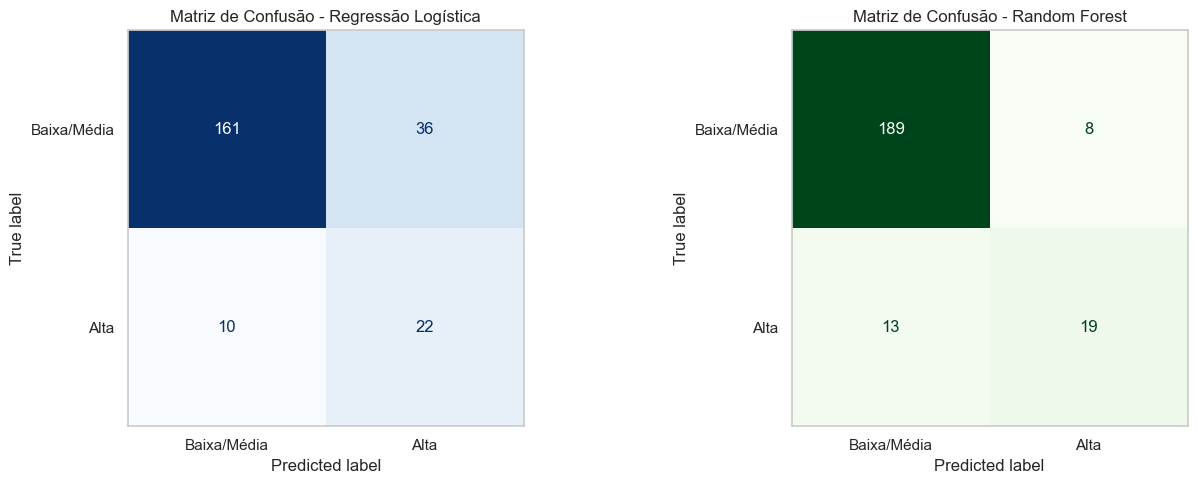

In [12]:
# --- PREVISÕES ---
y_pred_log = log_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

# --- AVALIAÇÃO: REGRESSÃO LOGÍSTICA ---
print("="*50)
print("RELATÓRIO DE CLASSIFICAÇÃO: REGRESSÃO LOGÍSTICA")
print("="*50)
print(classification_report(y_test, y_pred_log, target_names=["Baixa/Média (0)", "Alta (1)"]))

# --- AVALIAÇÃO: RANDOM FOREST ---
print("\n" + "="*50)
print("RELATÓRIO DE CLASSIFICAÇÃO: RANDOM FOREST")
print("="*50)
print(classification_report(y_test, y_pred_rf, target_names=["Baixa/Média (0)", "Alta (1)"]))

# Visualização das Matrizes de Confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Logística
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Baixa/Média", "Alta"])
disp_log.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão - Regressão Logística')
axes[0].grid(False)

# Matriz Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Baixa/Média", "Alta"])
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de Confusão - Random Forest')
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 10. Interpretabilidade do Negócio (Feature Importance)
Uma das maiores vantagens da *Random Forest* é a sua capacidade de nos dizer quais as características que mais pesaram na decisão final.

Isto é ouro para o nosso *Storytelling* Executivo: em vez de apenas entregarmos um modelo matemático aos produtores de vinho, podemos indicar-lhes exatamente onde devem focar os seus esforços no controlo de qualidade e na fermentação.

C:\Users\athos\AppData\Local\Temp\ipykernel_27840\746163162.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Feature', data=df_importances, palette='mako')


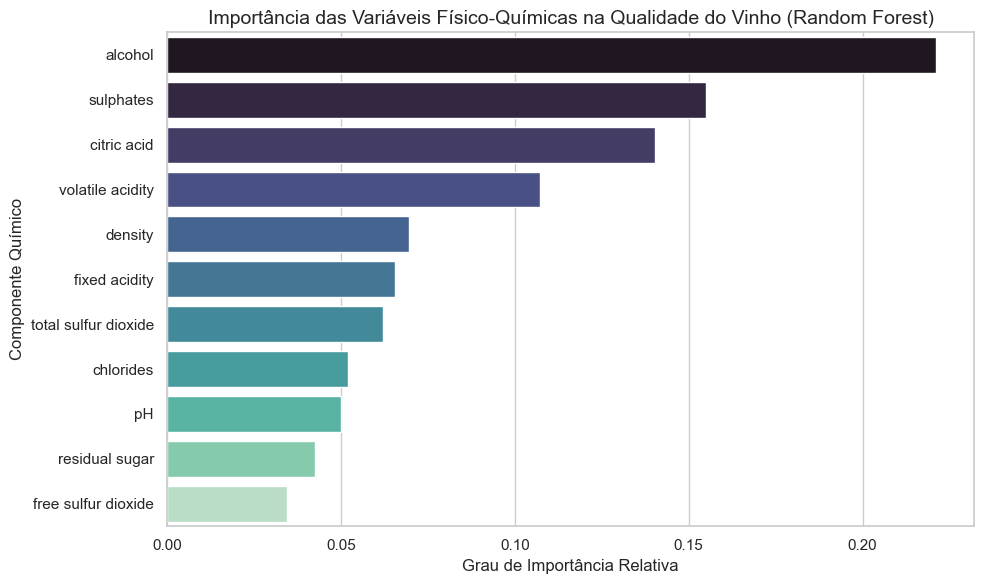

In [13]:
# Extraindo a importância das variáveis do modelo Random Forest
importances = rf_model.feature_importances_
features = X.columns

# Criando um DataFrame para facilitar a visualização
df_importances = pd.DataFrame({'Feature': features, 'Importância': importances})
df_importances = df_importances.sort_values(by='Importância', ascending=False)

# Visualização da Importância das Variáveis
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Feature', data=df_importances, palette='mako')
plt.title('Importância das Variáveis Físico-Químicas na Qualidade do Vinho (Random Forest)', fontsize=14)
plt.xlabel('Grau de Importância Relativa')
plt.ylabel('Componente Químico')
plt.tight_layout()
plt.show()

## 11. Conclusões e Recomendações Executivas

Através do desenvolvimento desta solução preditiva, alcançámos os objetivos propostos pelo *Tech Challenge*:

1. **Desempenho dos Modelos:** * A aplicação do balanceamento de classes (`class_weight='balanced'`) foi crucial para evitar que o algoritmo ignorasse os vinhos *premium* (minoria dos dados).
   * A *Random Forest* apresentou-se como a abordagem mais robusta, conseguindo capturar com boa eficácia (bom *Recall*) a classe minoritária, sem sacrificar em demasia a precisão global, algo evidenciado pela sua Matriz de Confusão mais ajustada em comparação com o modelo de base.

2. **Acionabilidade para o Negócio (Insights Acionáveis):**
   * O modelo confirmou estatisticamente as nossas suspeitas da Análise Exploratória. O **Teor Alcoólico (`alcohol`)** é, de longe, o fator mais determinante para que um vinho atinja a nota máxima dos especialistas.
   * A **Acidez Volátil (`volatile acidity`)** e os níveis de **Sulfatos (`sulphates`)** compõem os outros dois pilares da qualidade.
   * **Recomendação aos Produtores:** A vinícola deve investir em tecnologias de monitorização da fermentação para otimizar a extração de álcool e controlar rigorosamente a acidez volátil (que, em excesso, destrói a perceção de qualidade).

O modelo resultante já está preparado para receber novas amostras físico-químicas em tempo real (diretamente dos laboratórios da vinícola) e emitir alertas de probabilidade de qualidade, poupando tempo valioso aos enólogos avaliadores.